# view recommendation

From a homogeneous BRDF sphere setup, a view is a pixel taken from the rendered image.

In [1]:
import time
# SYNTHETIC SCENE SETUP
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image
from ivt.sampling import sample_sphere


from matplotlib import pyplot as plt
import torch
import numpy as np
from tqdm.notebook import tqdm

scene = Scene()

# material
SPECULAR=0.04
scene.set('mat', MicrofacetBRDF(0.3, SPECULAR, 0.3))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 1
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)
for i, origin in enumerate(sample_sphere(num_sensors, radius, 'fibonacci')):
    scene.set(f'sensor {i}', PerspectiveCamera.from_lookat(fov, origin, target, up))

# render target images
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't update changes in spp, workaround here to render a higher spp target image
renders = torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in tqdm(range(100))])

  0%|          | 0/100 [00:00<?, ?it/s]

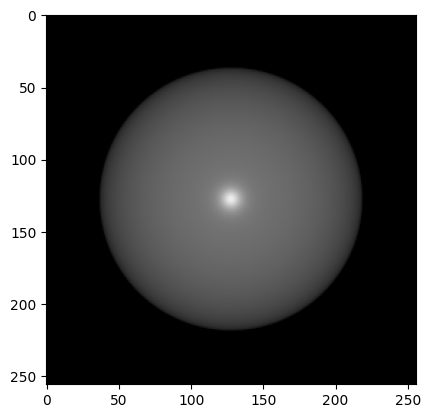

In [2]:
I_t = renders.mean(axis=0)
stddev = renders.std(axis=0)
target = I_t[0,128,0:129,1]
target_dev = stddev[0,128,0:129,1]

# Visualize a target Image
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
showimg(I_t)

In [3]:
# render images on D&R, fix S parameter combinations
import math
from math import sqrt, pi

def image(x):
    xo = x.cuda()
    scene['mat']['d'] = xo[0]
    scene['mat']['s'] = xo[1]
    scene['mat']['r'] = xo[2]
    img = renderer(scene)
    I = img[0,128,0:129,1]
    return I

# cache images
sobol_engine = torch.quasirandom.SobolEngine(dimension=2, scramble=True, seed=None)
n_cache = 20000
samples = sobol_engine.draw(n_cache)
samples = torch.vstack((samples[:,0], torch.full((n_cache,), 0.04), samples[:,1])).transpose(1, 0)
cached_uniform_samples = samples
cached_Is = torch.vstack([image(x) for x in tqdm(samples)])

  0%|          | 0/20000 [00:00<?, ?it/s]

In [ ]:
# from scipy.integrate import nquad
# # VALIDATION: compare MC integrated entropy with result of density estimation. They should be the same.
# def plot_kde(kde):
#     # Create a grid to evaluate the KDE
#     x = np.linspace(-0.1, 1.1, 200)
#     y = np.linspace(-0.1, 1.1, 200)
#     X, Y = np.meshgrid(x, y)
#     gridpoints = np.array([X.ravel(), Y.ravel()]).T
    
#     # Evaluate KDE on grid points
#     Z = np.exp(kde.score_samples(gridpoints)).reshape(X.shape)
    
#     # Plot the results using a contour plot
#     plt.contourf(X, Y, Z, cmap="Blues")
#     plt.colorbar(label="Density")
# #     plt.scatter(samples_np[:, 0], samples_np[:, 1], color='red', s=10, label='Data Points')
#     plt.xlabel("X-axis")
#     plt.ylabel("Y-axis")
#     plt.legend()
#     plt.title("Kernel Density Estimation (2D)")
#     plt.show()
    
# def validate_param_entropy(observed_pixels):
#     observed_pixels = to_tuple(observed_pixels)
#     # compute current posterior distribution of parameters
#     sigma = torch.tensor(0.05)
#     lpdf = (cached_Is - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()
#     Us = lpdf[..., observed_pixels].sum(axis=-1)
#     minU = Us.min().item()
#     log_phat = (minU - Us)
#     phat = log_phat.exp() # proportional to density of distribution
    
#     # compute entropy directly, based on phat which is proportional to density
#     n_sample = phat.shape[0]
#     integ_phat = phat.sum() / n_sample
#     integ_phat_log_phat = (phat * log_phat).sum() / n_sample
#     h = -integ_phat_log_phat / integ_phat + integ_phat.log()
#     h = h.item()

#     # resample using golden-ratio sampler
#     gratio = (math.sqrt(5)-1)/2
#     rej = torch.frac(torch.tensor([gratio*(i+1) for i in range(n_sample)]))
#     resampled = [cached_uniform_samples[i] for i in range(n_sample) if rej[i] < phat[i]]
#     resampled = torch.vstack(resampled).numpy()[..., ::2]
#     plt.scatter(resampled[...,0], resampled[..., 1], s=1)
    
#     # compute entropy using density estimation
#     kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(resampled)
#     plot_kde(kde)
    
#     # Numerically integrate using scipy's quad function
#     t0 = time.time()
#     def integrand(*x):
#         log_p = kde.score_samples([[*x]])
#         p = np.exp(log_p)
#         return -p * log_p if p>0 else 0.0
#     lower_limit = resampled.min(axis=0) - 3 * resampled.std(axis=0)
#     upper_limit = resampled.max(axis=0) + 3 * resampled.std(axis=0)
#     h1, _ = nquad(integrand, np.vstack((lower_limit, upper_limit)).T)
#     print("time:", time.time()-t0)
    
#     # alternatively eval KDE at resampled points only
#     t0 = time.time()
#     log_p = kde.score_samples(resampled)
#     h2 = -log_p.mean()
#     print("time:", time.time()-t0)
    
#     print(h, 'vs', h1, 'vs', h2)
    

# validate_param_entropy((120))

In [4]:
# from sklearn.neighbors import KernelDensity
# from scipy.integrate import quad

def to_tuple(px):
    if isinstance(px, tuple):
        return px
    return (px,)

def kde_entropy(samples, bandwidth=0.05):
    """
    Estimate the entropy of a continuous distribution based on samples using KDE.
    
    Parameters:
    - samples (torch.Tensor): 1D tensor of samples drawn from the distribution.
    - bandwidth (float, optional): Bandwidth for the KDE. If not provided, will use the Silverman's rule of thumb.
    
    Returns:
    - float: Estimated entropy of the distribution.
    """
    
    n = samples.size(0)
    # If bandwidth is not provided, use Silverman's rule of thumb
    if bandwidth is None:
        std_dev = torch.std(samples)
        bandwidth = 1.06 * std_dev * n ** (-1/5)
        
#     kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(samples)
#     h = -kde.score_samples(samples).mean()

    # To integrate over kde, we use MC integration,
    # importance sampling the reconstructed function
    # by perturbing the samples using the same kernel.
    # We may use more samples to reduce variance of estimation.
    samples_perturbed = samples.repeat(max(4000000//(n*n), 4))
    samples_perturbed += torch.randn_like(samples_perturbed) * bandwidth
    
    pairwise_diff = samples[:, None] - samples_perturbed[None, :]
    kde_values = (1 / (n * bandwidth * math.sqrt(2 * math.pi))) * (-0.5 * (pairwise_diff / bandwidth) ** 2).exp().sum(dim=0) 
    kde_values = kde_values.clamp(min=1e-8)
    entropy = -kde_values.log().mean()
    return entropy.item()

def gaussian_entropy(sigma):
    """
    compute entropy of a 1D gaussian distribution with standard deviation = sigma
    """
    return math.log(sigma * math.sqrt(2*math.pi)) + 0.5

def golden_resample(source_samples, p):
    n = source_samples.shape[0]
    g = torch.frac((math.sqrt(5)-1)/2 * torch.arange(1, n+1).cuda())
    return source_samples[g < p]
        
def view_recommend(observed_pixels, maxsample=1000):
    observed_pixels = to_tuple(observed_pixels)
    # compute current posterior distribution of parameters
    sigma = torch.tensor(0.05)
    lpdf = (cached_Is - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()
    Us = lpdf[..., observed_pixels].sum(axis=-1)
    minU = Us.min().item()
    log_phat = (minU - Us)
    phat = log_phat.exp() # proportional to density of distribution
    
    Is = golden_resample(cached_Is, phat)
    print("sample size:", Is.shape[0])
#     theta = golden_resample(cached_uniform_samples, phat)
#     plt.scatter(theta[:,0], theta[:,2], s=1)
    # for each view, estimate entropy of its incident radiance
    mutualI = []
    for view in tqdm(range(Is.shape[-1])):
        radiance_samples = Is[:maxsample,view]
        h = kde_entropy(radiance_samples)
        h_cond = gaussian_entropy(sigma=0.05)
        mutualI.append(h - h_cond)
    print("recommended view:", mutualI.index(max(mutualI)))
    return mutualI

In [16]:
from scipy.interpolate import griddata
def plot_contour_from_samples(x, y, z, res=300):
    # Create a grid to interpolate onto
    grid_x = np.linspace(0, 1, res)
    grid_y = np.linspace(0, 1, res)
    grid_X, grid_Y = np.meshgrid(grid_x, grid_y)
    # Interpolate using griddata
    grid_Z = griddata((x, y), z, (grid_X, grid_Y), method='cubic').clip(min=0, max=1)

    # Plotting
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(grid_X, grid_Y, grid_Z, levels=np.linspace(0,1,41))
    plt.colorbar(contour)
#     plt.scatter(x, y, color='k', s=1, alpha=0.5, label="Sample Points")
    plt.title("Distribution of parameter (visualized from Samples)")
    plt.xlabel("theta[0]: diffuse")
    plt.ylabel("theta[1]: roughness")
    plt.legend()
    plt.grid(True)
    plt.show()
    
def posterior_entropy(observed_pixels, plot=False):
    observed_pixels = to_tuple(observed_pixels)
    sigma = torch.tensor(0.05)
    lpdf = (cached_Is - target).pow(2.0) / (2.0 * sigma.pow(2.0)) + (sigma*sqrt(2*pi)).log()
    Us = lpdf[..., observed_pixels].sum(axis=-1)
    minU = Us.min().item()
    log_phat = (minU - Us)
    phat = log_phat.exp()
    
    if plot:
#         plt.contourf(cached_uniform_samples.cpu()[:,0], cached_uniform_samples.cpu()[:,2], phat.cpu())
        plot_contour_from_samples(cached_uniform_samples.cpu()[:,0], cached_uniform_samples.cpu()[:,2], phat.cpu())
        
    # compute entropy based on phat which is proportional to density
    n_sample = phat.shape[0]
    integ_phat = phat.sum() / n_sample
    integ_phat_log_phat = (phat * log_phat).sum() / n_sample
    h = -integ_phat_log_phat / integ_phat + integ_phat.log()
    return h.item()

def added_view_result(observed_pixels):
    observed_pixels = to_tuple(observed_pixels)
    Is = cached_Is
    h = []
    for view in tqdm(range(Is.shape[-1])):
        if view in observed_pixels:
            h.append(float('nan'))
        else:
            updated_observation = tuple(set((*observed_pixels, view)))
            h.append(posterior_entropy(updated_observation))
    return h

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


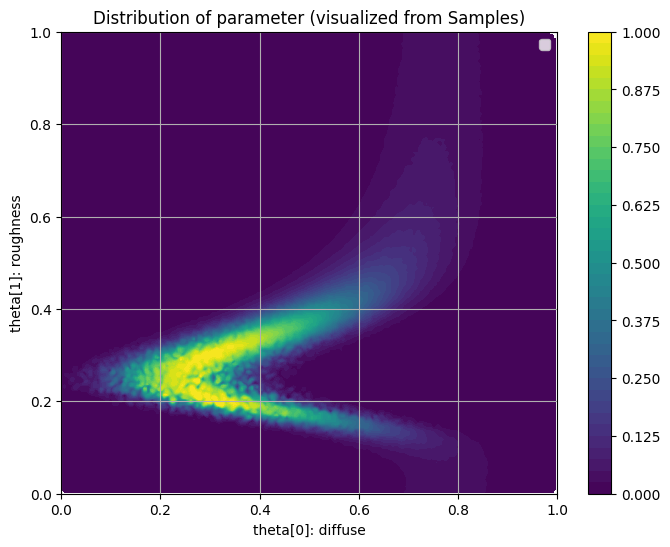

-1.7183318138122559

In [22]:
a = np.random.randint(37, 129)
b = np.random.randint(37, 129)
posterior_entropy((a,b), plot=True)

In [25]:
def experiment_recommendation(px):
    current_h = posterior_entropy(px, plot=True)
    print("current entropy:", current_h)
    heuristics = view_recommend(px)
    results = np.array(added_view_result(px))
    plt.plot(heuristics, label="estimated mutual information of view")
    plt.plot(current_h - results, label="entropy decrease after adding view")
    plt.xlabel("view (pixel index)")
    for x in px:
        plt.axvline(x, color='gray', linestyle='--', label='existing observation', alpha=0.7)
    plt.plot()
    plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


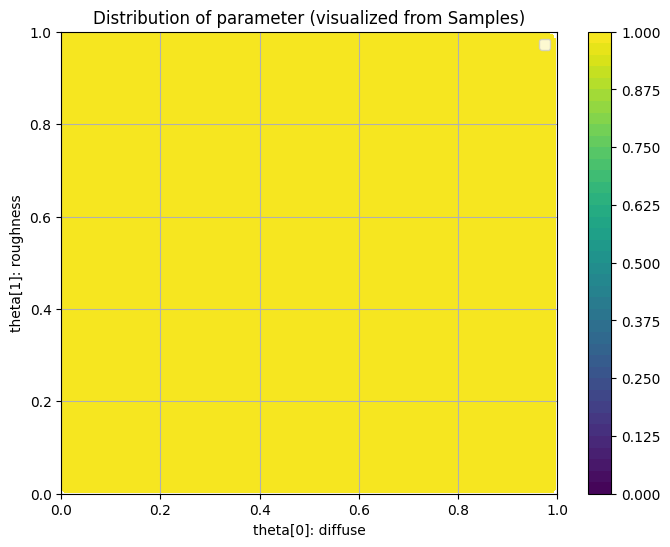

current entropy: 0.0
sample size: 20000


  0%|          | 0/129 [00:00<?, ?it/s]

recommended view: 128


  0%|          | 0/129 [00:00<?, ?it/s]

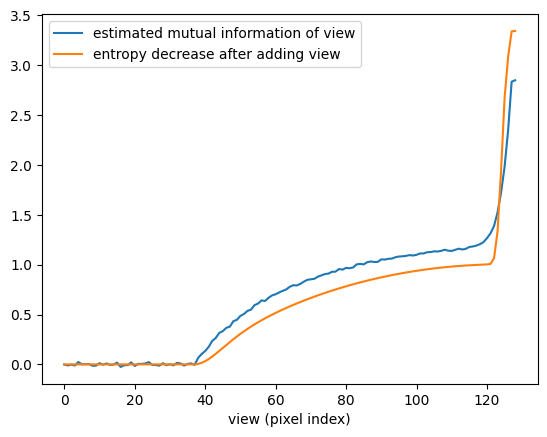

In [26]:
experiment_recommendation(())

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


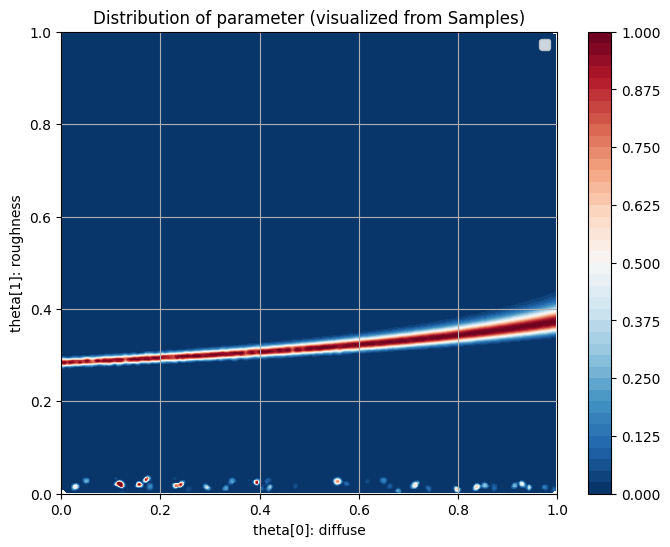

current entropy: -3.340390205383301
sample size: 429


  0%|          | 0/129 [00:00<?, ?it/s]

recommended view: 117


  0%|          | 0/129 [00:00<?, ?it/s]

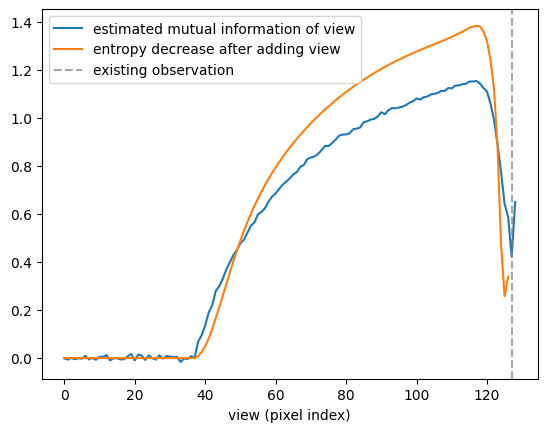

In [82]:
experiment_recommendation((127,))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


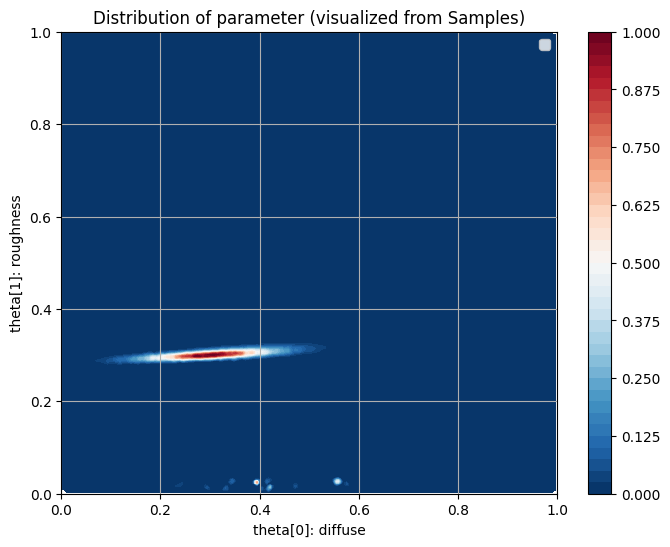

current entropy: -4.723587512969971
sample size: 72


  0%|          | 0/129 [00:00<?, ?it/s]

recommended view: 128


  0%|          | 0/129 [00:00<?, ?it/s]

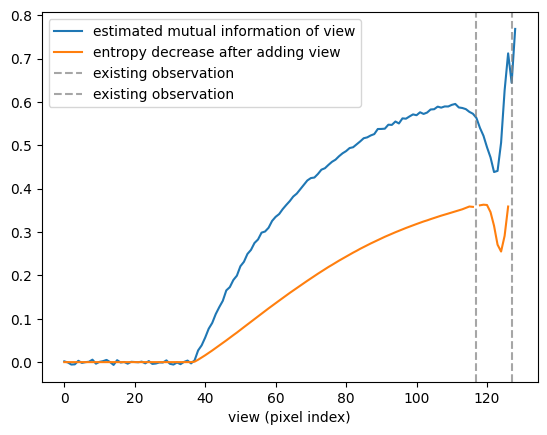

In [83]:
experiment_recommendation((127, 117))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


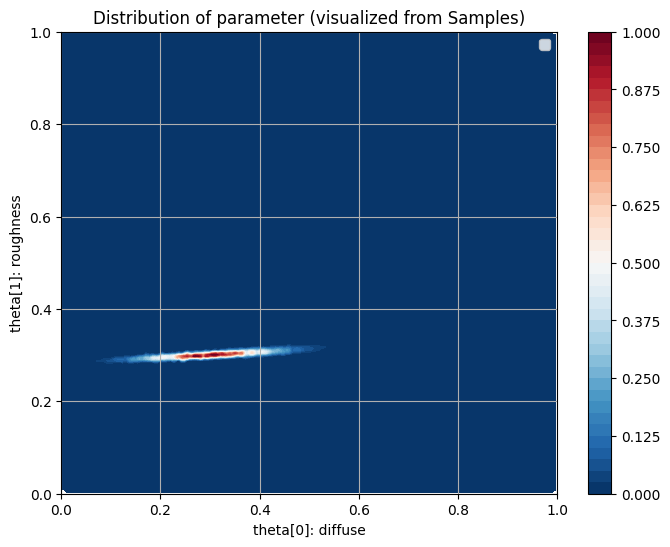

current entropy: -5.133645534515381
sample size: 49


  0%|          | 0/129 [00:00<?, ?it/s]

recommended view: 113


  0%|          | 0/129 [00:00<?, ?it/s]

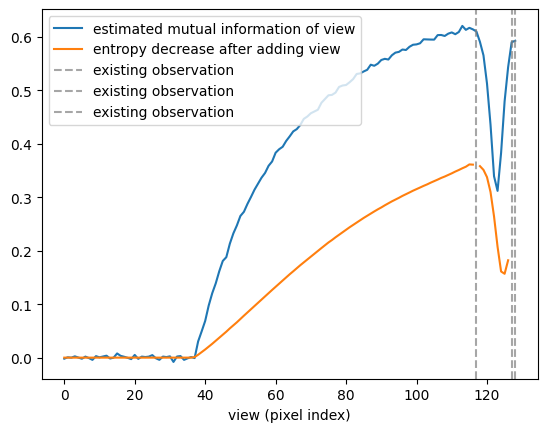

In [84]:
experiment_recommendation((128, 117, 127))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


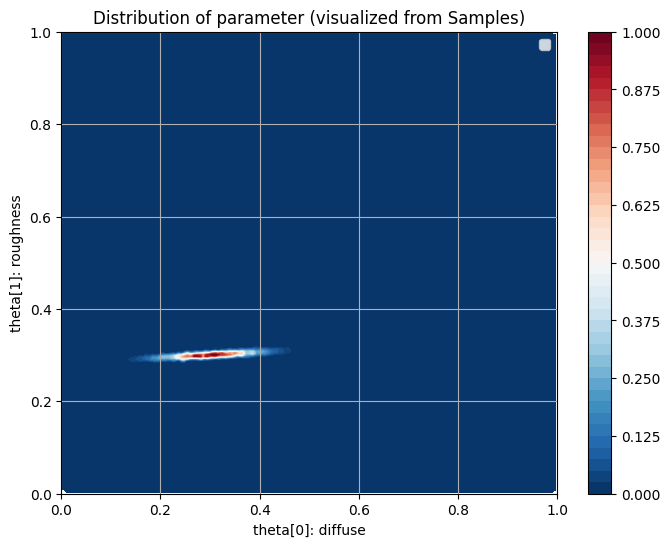

current entropy: -5.487647533416748
sample size: 41


  0%|          | 0/129 [00:00<?, ?it/s]

recommended view: 128


  0%|          | 0/129 [00:00<?, ?it/s]

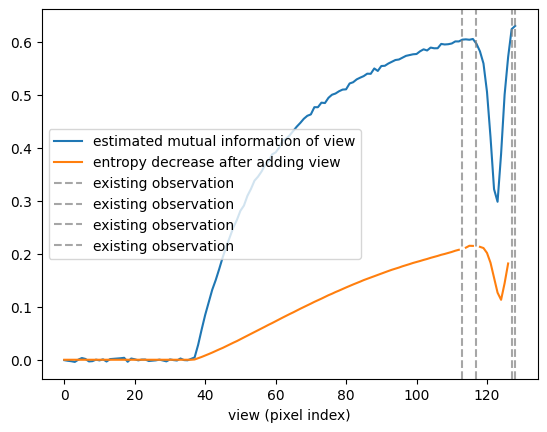

In [85]:
experiment_recommendation((128, 113, 127, 117))

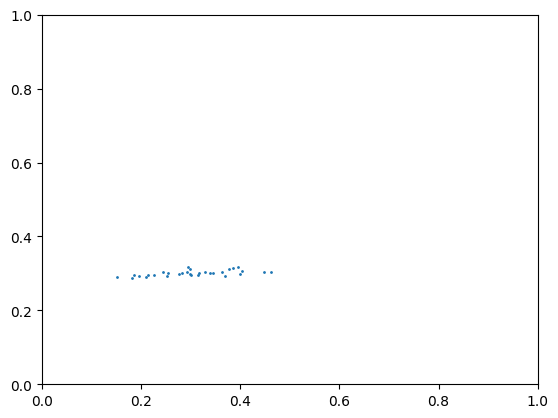